In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Question 2.2: Decision Tree Classifier

## Dataset Loading

In [5]:
import kagglehub
import pandas as pd
import os

# Download the Chronic Kidney Disease (CKD) dataset from KaggleHub
path = kagglehub.dataset_download("mansoordaku/ckdisease")

print(f"Path to dataset files: {path}")

100%|██████████| 9.51k/9.51k [00:00<00:00, 14.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mansoordaku/ckdisease/versions/1


## Dataset Inspection

In [6]:
# 1. Downloaded files
print("Downloaded files:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

# Identify the actual CKD dataset file (assuming it's a CSV in the downloaded path)
# Based on typical Kaggle datasets, it's often a CSV directly in the downloaded folder.
data_file = os.path.join(path, 'kidney_disease.csv') # Common filename for this dataset

# 2. Selected data file
print(f"\nSelected data file: {data_file}")

# Load the dataset into a pandas DataFrame
try:
    df = pd.read_csv(data_file)
except FileNotFoundError:
    print(f"Error: The file {data_file} was not found. Please verify the dataset path and filename.")
    # Try to find a CSV file if the default name didn't work
    csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
    if csv_files:
        data_file = os.path.join(path, csv_files[0])
        print(f"Attempting to load: {data_file}")
        df = pd.read_csv(data_file)
    else:
        raise ValueError("No CSV file found in the downloaded directory.")

# 3. Dataset shape
print(f"\nDataset shape: {df.shape}")

# 4. Column names
print("\nColumn names:")
print(df.columns.tolist())

# 5. Data types
print("\nData types:")
print(df.info())

# 6. First five rows
print("\nFirst five rows:")
display(df.head())

Downloaded files:
/root/.cache/kagglehub/datasets/mansoordaku/ckdisease/versions/1/kidney_disease.csv

Selected data file: /root/.cache/kagglehub/datasets/mansoordaku/ckdisease/versions/1/kidney_disease.csv

Dataset shape: (400, 26)

Column names:
['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


## Data Preprocessing

In [7]:
import numpy as np
import pandas as pd # Ensure pandas is imported
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Drop 'id' column as it's just an identifier and not a feature
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Clean and convert 'object' columns that should be numeric
# 'pcv', 'wc', 'rc' might contain '\t' and need conversion to numeric
for col in ['pcv', 'wc', 'rc']:
    if col in df.columns:
        # Convert to string first to use .str methods, then clean specific characters
        cleaned_col = df[col].astype(str).str.replace('\t', '', regex=False)
        cleaned_col = cleaned_col.str.replace('\t?', '', regex=False)
        cleaned_col = cleaned_col.str.strip()
        # Replace any remaining empty strings or whitespace-only strings with NaN before converting to numeric
        df[col] = cleaned_col.replace(r'^\s*$', np.nan, regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Standardize binary categorical columns
binary_categorical_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

for col in binary_categorical_cols:
    if col in df.columns:
        # Convert to string, strip whitespace, and convert to lowercase for standardization
        df[col] = df[col].astype(str).str.strip().str.lower()
        # Replace any '?' or empty strings with NaN
        df[col] = df[col].replace({'?': np.nan, '': np.nan})

# Define the cleaned mappings for binary categorical columns
binary_cols_mapping = {
    'rbc': {'normal': 1, 'abnormal': 0},
    'pc': {'normal': 1, 'abnormal': 0},
    'pcc': {'present': 1, 'notpresent': 0},
    'ba': {'present': 1, 'notpresent': 0},
    'htn': {'yes': 1, 'no': 0},
    'dm': {'yes': 1, 'no': 0},
    'cad': {'yes': 1, 'no': 0},
    'appet': {'good': 1, 'poor': 0},
    'pe': {'yes': 1, 'no': 0},
    'ane': {'yes': 1, 'no': 0}
}

for col, mapping in binary_cols_mapping.items():
    if col in df.columns:
        # Apply the simplified mapping now that strings are clean
        df[col] = df[col].replace(mapping).astype(float)

# Target encoding: CKD = 1, Not CKD = 0
# Clean the classification column similarly before mapping
df['classification'] = df['classification'].astype(str).str.strip().str.lower() \
                                         .replace({'ckd': 1, 'notckd': 0}) \
                                         .astype(int)

# Separate features (X) and target (y)
X = df.drop('classification', axis=1)
y = df['classification']

# Identify numerical and categorical features after cleaning and initial type conversions
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

# Define preprocessing steps (these remain the same as they handle imputation and encoding within pipelines)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # Change from 'passthrough' to 'drop'
)

print("\nPreprocessing pipelines defined.")

/tmp/ipykernel_1370/3987134855.py:57: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({'ckd': 1, 'notckd': 0}) \



Numerical features: ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
Categorical features: []

Preprocessing pipelines defined.


## Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# Using the same 80% training and 20% testing split as Question 2.1
# with random_state=42 and stratify=y for consistent and representative splits.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nTrain-test split completed with 80% training and 20% testing data.")

X_train shape: (320, 24)
X_test shape: (80, 24)
y_train shape: (320,)
y_test shape: (80,)

Train-test split completed with 80% training and 20% testing data.


## Decision Tree Baseline Model

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create the Decision Tree Classifier pipeline
# Do NOT apply StandardScaler unnecessarily to the Decision Tree model as per assignment.
# Preprocessor already handles imputation and one-hot encoding.
dtree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Train the Decision Tree classifier
dtree_pipeline.fit(X_train, y_train)

print("Decision Tree Baseline Model trained.")

Decision Tree Baseline Model trained.


## Baseline Model Evaluation

In [10]:
# Predict on the test set
y_pred = dtree_pipeline.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nBaseline Decision Tree Model Performance on Test Set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Baseline Decision Tree Model Performance on Test Set:
Accuracy: 0.9750
Precision: 1.0000
Recall: 0.9600
F1-Score: 0.9796


## Hyperparameter Tuning

We will now perform hyperparameter tuning using `GridSearchCV` to find the best configuration for our Decision Tree Classifier. The hyperparameters to tune are `max_depth`, `min_samples_split`, and `criterion`. We will use 5-fold cross-validation on the training data.

In [11]:
import time
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define the parameter grid for GridSearchCV
param_grid = {
    'classifier__max_depth': [3, 5, 7, 10, None], # None means unlimited depth
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__criterion': ['gini', 'entropy']
}

# Define multi-metric scoring
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# Instantiate GridSearchCV
# We will use F1-score as the primary metric for choosing the best model, as specified in the assignment.
grid_search = GridSearchCV(
    estimator=dtree_pipeline, # Use our existing pipeline
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring=scoring, # Use multi-metric scoring
    refit='f1', # Select the best configuration based on the highest mean cross-validated F1-Score
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV on the training data
print("Starting GridSearchCV...")
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()
print("GridSearchCV completed.")

training_time_dt = end_time - start_time

# Get the best parameters and best score
best_params = grid_search.best_params_
best_f1_score = grid_search.best_score_

print(f"\nBest hyperparameters found: {best_params}")
print(f"Best F1-score (from cross-validation): {best_f1_score:.4f}")

# Store the best model
best_dt_model = grid_search.best_estimator_

Starting GridSearchCV...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
GridSearchCV completed.

Best hyperparameters found: {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_split': 20}
Best F1-score (from cross-validation): 0.9925


### Hyperparameter Comparison Table

Let's create a table to compare the performance of different hyperparameter configurations based on their cross-validation results.

In [12]:
import pandas as pd

# Get all results from GridSearchCV
results = pd.DataFrame(grid_search.cv_results_)

# Select relevant columns for comparison, now including all mean test scores from multi-metric scoring
results_table = results[['param_classifier__max_depth', 'param_classifier__min_samples_split',
                         'param_classifier__criterion', 'mean_test_accuracy', 'mean_test_precision',
                         'mean_test_recall', 'mean_test_f1', 'std_test_f1']]

# Rename columns for better readability
results_table = results_table.rename(columns={
    'param_classifier__max_depth': 'Max Depth',
    'param_classifier__min_samples_split': 'Min Samples Split',
    'param_classifier__criterion': 'Criterion',
    'mean_test_accuracy': 'Mean CV Accuracy',
    'mean_test_precision': 'Mean CV Precision',
    'mean_test_recall': 'Mean CV Recall',
    'mean_test_f1': 'Mean CV F1-Score',
    'std_test_f1': 'Std Dev F1-Score (CV)'
})

# Sort by Mean F1-Score in descending order, as F1 was chosen for refit
results_table = results_table.sort_values(by='Mean CV F1-Score', ascending=False)

print("Hyperparameter Tuning Results (Sorted by Mean CV F1-Score):")
display(results_table)

Hyperparameter Tuning Results (Sorted by Mean CV F1-Score):


,Max Depth,Min Samples Split,Criterion,Mean CV Accuracy,Mean CV Precision,Mean CV Recall,Mean CV F1-Score,Std Dev F1-Score (CV)
27,5,20,entropy,0.990625,0.990122,0.995,0.992531,0.009985
31,7,20,entropy,0.990625,0.990122,0.995,0.992531,0.009985
39,None,20,entropy,0.990625,0.990122,0.995,0.992531,0.009985
35,10,20,entropy,0.990625,0.990122,0.995,0.992531,0.009985
5,5,5,gini,0.987500,0.985244,0.995,0.990062,0.009338
23,3,20,entropy,0.987500,0.985244,0.995,0.990062,0.009338
13,10,5,gini,0.987500,0.985244,0.995,0.990062,0.009338
9,7,5,gini,0.987500,0.985244,0.995,0.990062,0.009338
17,None,5,gini,0.987500,0.985244,0.995,0.990062,0.009338
24,5,2,entropy,0.984375,0.989859,0.985,0.987274,0.019862


### Hyperparameter Tuning Results Summary

Below is the summary table of the cross-validation results from `GridSearchCV`, sorted by Mean F1-Score (CV). This table helps us understand the performance of different hyperparameter combinations.

In [13]:
import pandas as pd

# Re-display the results table for context in this section
# Ensure `results` and `grid_search` are available from previous execution
if 'grid_search' in locals():
    results = pd.DataFrame(grid_search.cv_results_)
    # Select relevant columns for comparison, now including all mean test scores from multi-metric scoring
    results_table = results[['param_classifier__max_depth', 'param_classifier__min_samples_split',
                             'param_classifier__criterion', 'mean_test_accuracy', 'mean_test_precision',
                             'mean_test_recall', 'mean_test_f1', 'std_test_f1']]

    # Rename columns for better readability
    results_table = results_table.rename(columns={
        'param_classifier__max_depth': 'Max Depth',
        'param_classifier__min_samples_split': 'Min Samples Split',
        'param_classifier__criterion': 'Criterion',
        'mean_test_accuracy': 'Mean CV Accuracy',
        'mean_test_precision': 'Mean CV Precision',
        'mean_test_recall': 'Mean CV Recall',
        'mean_test_f1': 'Mean CV F1-Score',
        'std_test_f1': 'Std Dev F1-Score (CV)'
    })

    # Sort by Mean F1-Score in descending order, as F1 was chosen for refit
    results_table = results_table.sort_values(by='Mean CV F1-Score', ascending=False)

    print("Hyperparameter Tuning Results (Sorted by Mean CV F1-Score):")
    display(results_table)
else:
    print("GridSearchCV results not found. Please run the hyperparameter tuning section first.")

Hyperparameter Tuning Results (Sorted by Mean CV F1-Score):


,Max Depth,Min Samples Split,Criterion,Mean CV Accuracy,Mean CV Precision,Mean CV Recall,Mean CV F1-Score,Std Dev F1-Score (CV)
27,5,20,entropy,0.990625,0.990122,0.995,0.992531,0.009985
31,7,20,entropy,0.990625,0.990122,0.995,0.992531,0.009985
39,None,20,entropy,0.990625,0.990122,0.995,0.992531,0.009985
35,10,20,entropy,0.990625,0.990122,0.995,0.992531,0.009985
5,5,5,gini,0.987500,0.985244,0.995,0.990062,0.009338
23,3,20,entropy,0.987500,0.985244,0.995,0.990062,0.009338
13,10,5,gini,0.987500,0.985244,0.995,0.990062,0.009338
9,7,5,gini,0.987500,0.985244,0.995,0.990062,0.009338
17,None,5,gini,0.987500,0.985244,0.995,0.990062,0.009338
24,5,2,entropy,0.984375,0.989859,0.985,0.987274,0.019862


### Evaluation of the Best Model on the Unseen Test Set

The `best_dt_model` obtained from `GridSearchCV` has already been trained on the full `X_train` data using the optimal hyperparameters. We will now evaluate this model *once* on the `X_test` to report its final, unbiased performance.

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict on the unseen test set using the best model
y_pred_best = best_dt_model.predict(X_test)

# Calculate final evaluation metrics
final_accuracy = accuracy_score(y_test, y_pred_best)
final_precision = precision_score(y_test, y_pred_best)
final_recall = recall_score(y_test, y_pred_best)
final_f1 = f1_score(y_test, y_pred_best)

print(f"\nFinal Best Decision Tree Model Performance on Unseen Test Set:")
print(f"Accuracy: {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall: {final_recall:.4f}")
print(f"F1-Score: {final_f1:.4f}")
print(f"Training/Tuning Time: {training_time_dt:.4f} seconds")

# For comparison, re-state the baseline model's performance on the test set
print(f"\nBaseline Decision Tree Model Performance (for comparison):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Create dt_metrics dictionary
dt_metrics = {
    'Accuracy': final_accuracy,
    'Precision': final_precision,
    'Recall': final_recall,
    'F1-Score': final_f1,
    'Training Time (s)': training_time_dt
}

print("\nDecision Tree Metrics for Comparison:")
display(dt_metrics)


Final Best Decision Tree Model Performance on Unseen Test Set:
Accuracy: 0.9625
Precision: 1.0000
Recall: 0.9400
F1-Score: 0.9691
Training/Tuning Time: 10.6953 seconds

Baseline Decision Tree Model Performance (for comparison):
Accuracy: 0.9750
Precision: 1.0000
Recall: 0.9600
F1-Score: 0.9796

Decision Tree Metrics for Comparison:


{'Accuracy': 0.9625,
 'Precision': 1.0,
 'Recall': 0.94,
 'F1-Score': 0.9690721649484536,
 'Training Time (s)': 10.695288896560669}

## Feature Importance

Now, let's visualize the feature importance of the best Decision Tree model identified through hyperparameter tuning. Understanding feature importance helps us gain insights into which variables are most crucial for predicting Chronic Kidney Disease.

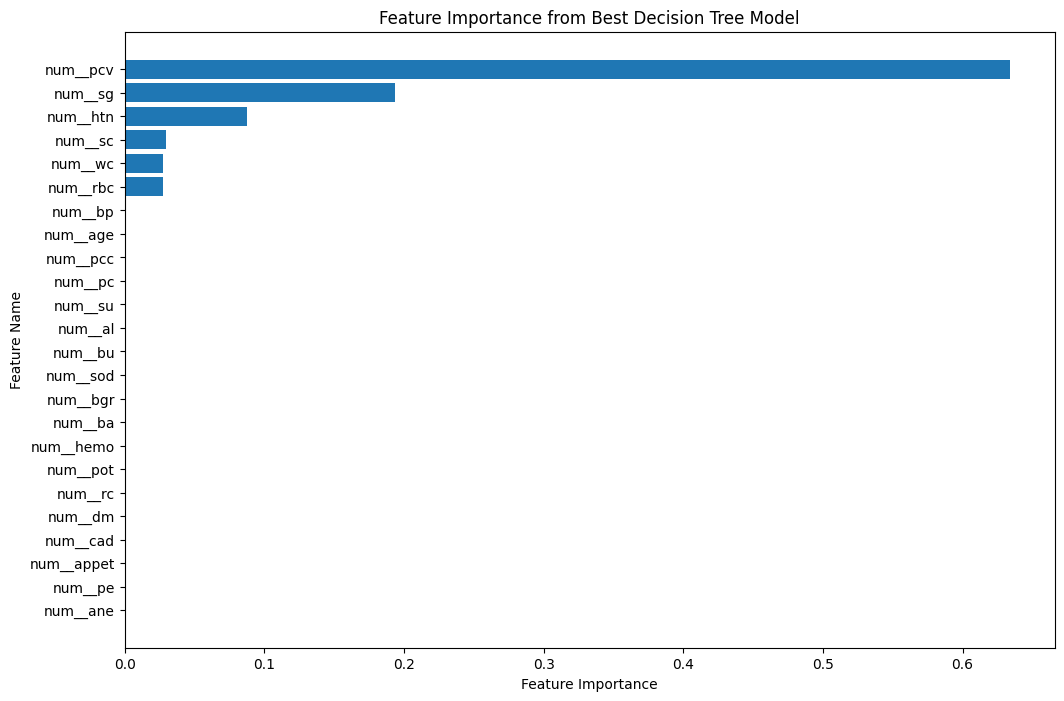

,Feature,Importance
15,num__pcv,0.634227
2,num__sg,0.193696
18,num__htn,0.087394
11,num__sc,0.029753
16,num__wc,0.027679
5,num__rbc,0.027251
1,num__bp,0.000000
0,num__age,0.000000
7,num__pcc,0.000000
6,num__pc,0.000000


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The best model is stored in best_dt_model
# We need to get the feature importances from the 'classifier' step of the pipeline.
feature_importances = best_dt_model.named_steps['classifier'].feature_importances_

# Get the feature names that the preprocessor outputs.
# The preprocessor is already fitted as part of grid_search.fit(X_train, y_train).
feature_names_post_preprocessing = best_dt_model.named_steps['preprocessor'].get_feature_names_out()

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names_post_preprocessing,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("Feature Importance from Best Decision Tree Model")
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

display(importance_df)

## Decision Tree Visualization

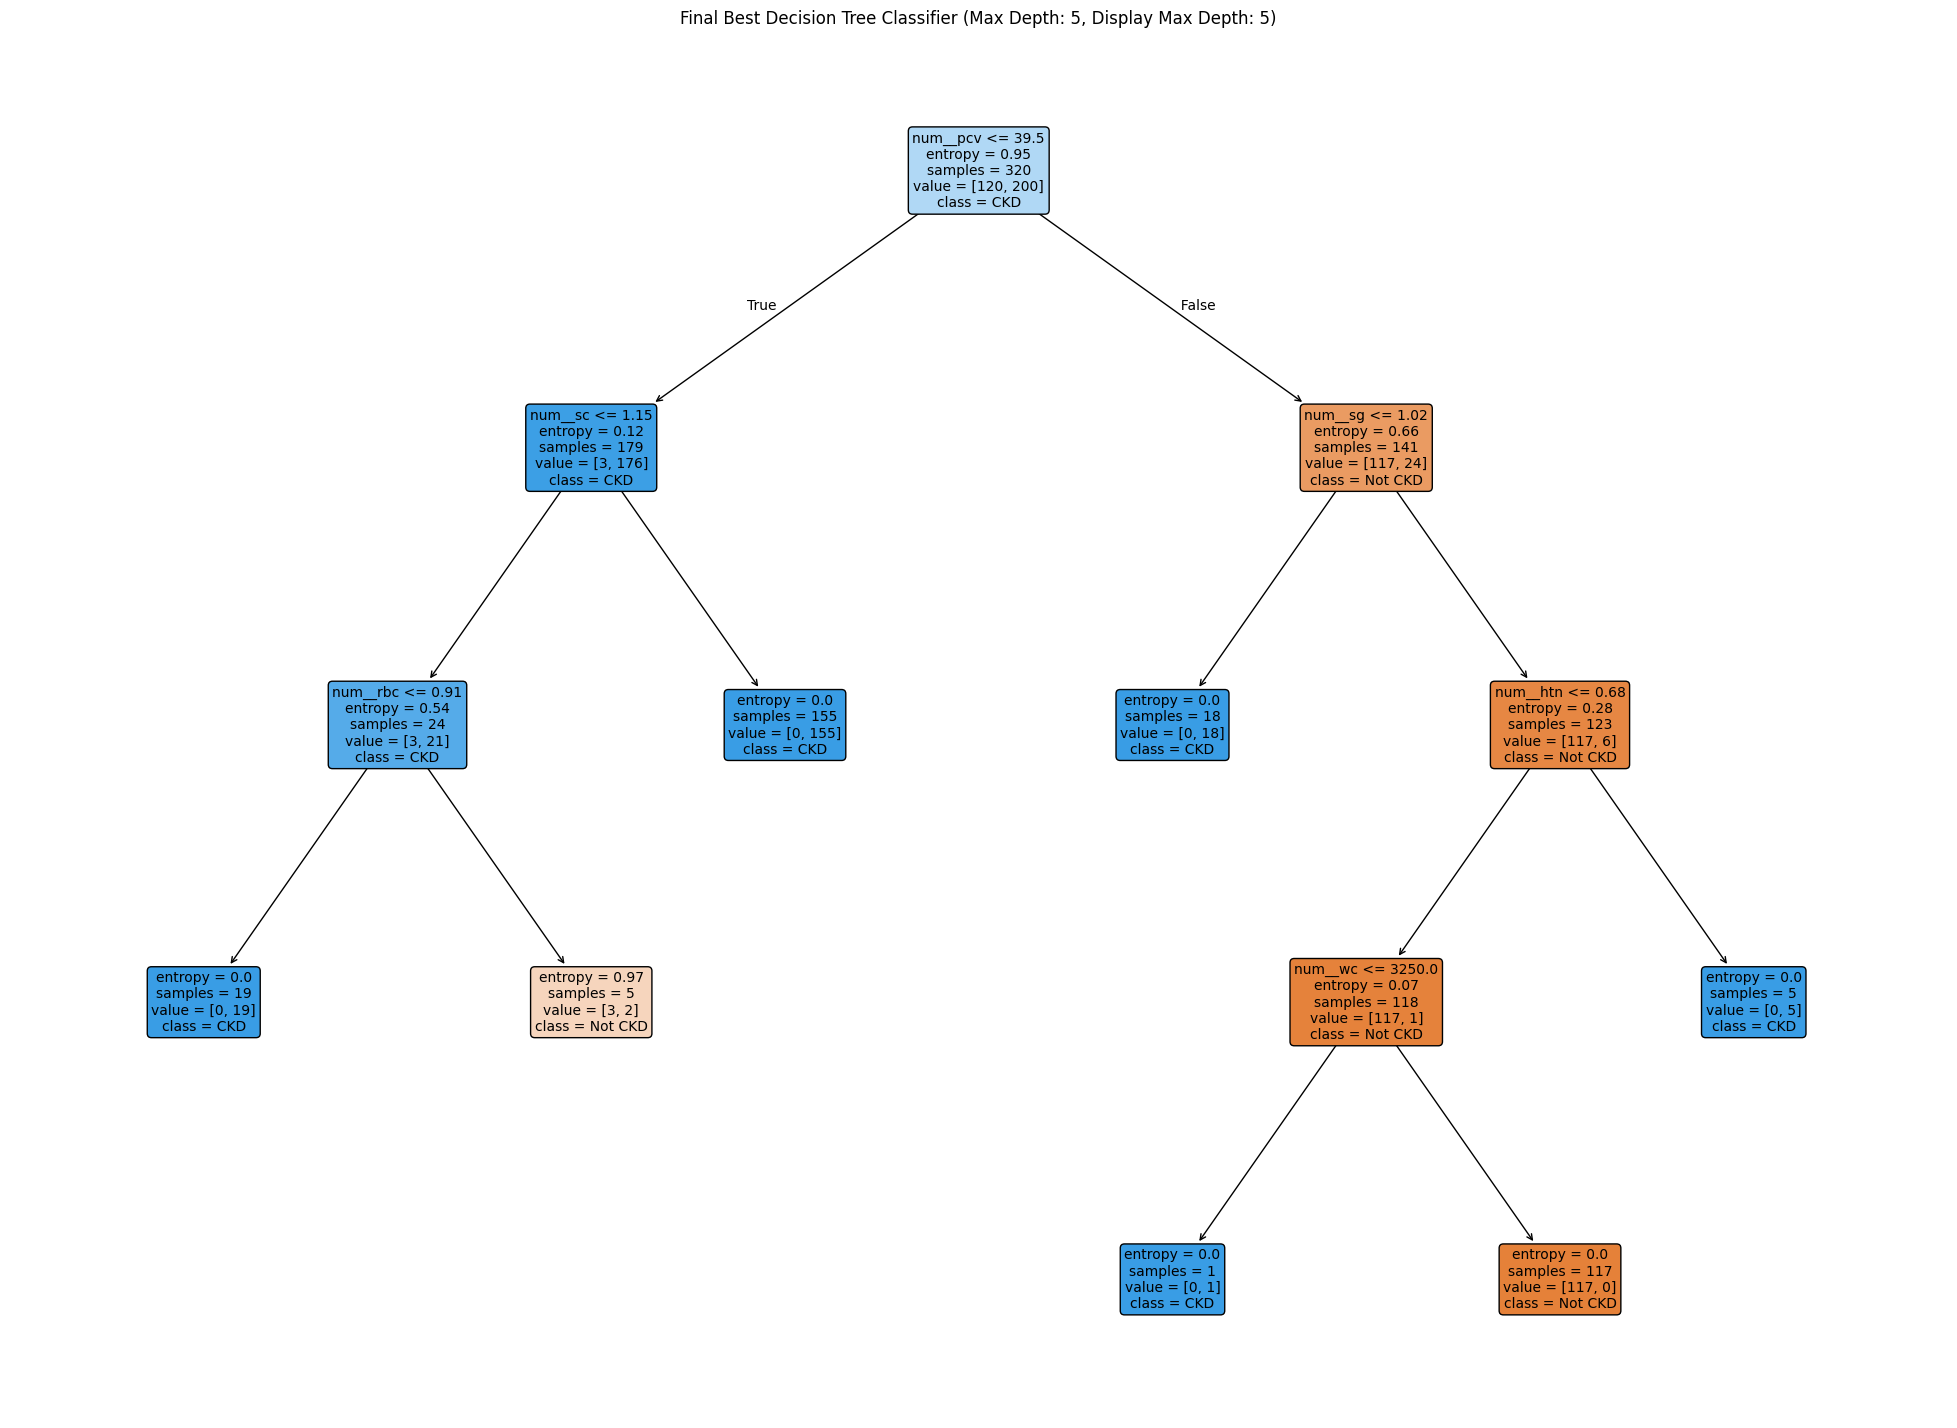

In [16]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Get the FINAL BEST Decision Tree Classifier from the best_dt_model pipeline
dt_classifier_best = best_dt_model.named_steps['classifier']

# Get feature names after preprocessing.
# The preprocessor is already fitted as part of grid_search.fit(X_train, y_train).
feature_names_for_best_model = best_dt_model.named_steps['preprocessor'].get_feature_names_out()

# Get the max_depth of the best model
best_max_depth = best_dt_model.named_steps['classifier'].max_depth

# For visualization, if the best_max_depth is very large or None, limit it for readability
# Otherwise, use the actual best_max_depth
visualization_max_depth = best_max_depth if best_max_depth is not None and best_max_depth < 10 else 5 # Limiting to 5 for readability

# Visualize the FINAL BEST Decision Tree
plt.figure(figsize=(25, 18))
plot_tree(
    dt_classifier_best,
    feature_names=feature_names_for_best_model,
    class_names=['Not CKD', 'CKD'], # Use specified class names
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=visualization_max_depth, # Use the actual best depth or limited for display
    precision=2 # Display feature values with 2 decimal places
)
plt.title(f"Final Best Decision Tree Classifier (Max Depth: {best_max_depth if best_max_depth is not None else 'None'}, Display Max Depth: {visualization_max_depth})")
plt.show()